# EDA: поисковый датасет объявлений (Avito Услуги)

Разведочный анализ данных из `dataset/` для задачи **поиска / ранжирования**
(query → релевантные объявления).

**Состав данных**

| Файл | Строк | Роль |
|---|---|---|
| `train.parquet` | 497 673 | обучающие пары «запрос → объявление» (денормализованные) |
| `benchmark_items.parquet` | 189 212 | корпус объявлений, в котором нужно искать |
| `benchmark_queries.parquet` | 2 452 | запросы бенчмарка |

**План анализа**

1. Загрузка и схема данных
2. Качество данных: пропуски, дубликаты, аномалии
3. Запросы: длина, лексика, гео, категории
4. Корпус объявлений: тексты, цена, рейтинг, гео, категории, дубликаты
5. Структура обучающих пар (что вообще является таргетом)
6. **Пересечение train ↔ benchmark**: утечка и доступная валидация
7. Лексическое пересечение «запрос ↔ объявление» (потолок BM25)
8. Структура `infm_params_text`
9. Выводы и следствия для модели


## 0. Настройка

Палитра и стиль графиков заданы один раз: единый синий последовательный
градиент для величин, фиксированный порядок категориальных цветов (никогда не
циклится), приглушённая сетка.

In [2]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

RANDOM_STATE = 42
SAMPLE_N = 60_000  # размер выборки для тяжёлых текстовых операций
rng = np.random.default_rng(RANDOM_STATE)

# --- палитра -----------------------------------------------------------------
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ)
INK, SECOND, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 9,
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlecolor": INK, "axes.titlepad": 12, "axes.titlelocation": "left",
    "axes.labelcolor": SECOND, "axes.labelsize": 9,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": SECOND, "ytick.labelcolor": SECOND,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 2, "lines.markersize": 5,
})


def style(ax, title=None, xlabel=None, ylabel=None, axis="y"):
    """Приглушённая сетка по одной оси + подписи."""
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis=axis, alpha=0.9)
    ax.set_axisbelow(True)
    return ax


def barh_top(ax, labels, values, color=SERIES[0], fmt="{:,.0f}", pad=0.01):
    """Горизонтальный бар-чарт с прямыми подписями значений (сверху — крупнейшее)."""
    y = np.arange(len(labels))
    ax.barh(y, values, color=color, height=0.68)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    span = max(values) if len(values) else 1
    for yi, v in zip(y, values):
        ax.text(v + span * pad, yi, fmt.format(v), va="center",
                fontsize=8, color=SECOND)
    ax.set_xlim(0, span * 1.18)
    ax.grid(axis="x", alpha=0.9)
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    return ax


def pct(x, total):
    return f"{100 * x / total:.1f}%"


TOKEN_RE = re.compile(r"\w+", re.UNICODE)


def tokenize(s):
    return TOKEN_RE.findall(str(s).lower())


RU_STOP = {
    "и", "в", "на", "с", "по", "для", "от", "до", "не", "за", "из", "к", "у",
    "о", "а", "под", "при", "или", "же", "что", "как", "the", "бу",
}
print("Настройка завершена.")

Настройка завершена.


## 1. Загрузка и схема

Файлы крупные (`train` ≈ 490 МБ), поэтому колонки грузятся выборочно:
длинные текстовые поля объявлений (`item_description_raw`,
`item_infm_params_text`) подтягиваются отдельно и сразу сворачиваются в
метрики, чтобы не держать ~1.2 ГБ строк в памяти.

In [3]:
DATA = Path("../dataset") if Path("../dataset").exists() else Path("dataset")
FILES = {
    "train": DATA / "train.parquet",
    "benchmark_items": DATA / "benchmark_items.parquet",
    "benchmark_queries": DATA / "benchmark_queries.parquet",
}

meta = []
for name, path in FILES.items():
    pf = pq.ParquetFile(path)
    meta.append({
        "файл": name,
        "размер, МБ": round(path.stat().st_size / 1024 ** 2, 1),
        "строк": pf.metadata.num_rows,
        "колонок": pf.metadata.num_columns,
        "row groups": pf.metadata.num_row_groups,
    })
pd.DataFrame(meta)

,файл,"размер, МБ",строк,колонок,row groups
0,train,467.5,497673,19,1
1,benchmark_items,186.6,189212,14,1
2,benchmark_queries,0.1,2452,6,1


In [4]:
schema = pq.ParquetFile(FILES["train"]).schema_arrow
pd.DataFrame({"колонка": schema.names,
              "тип": [str(t) for t in schema.types]})

,колонка,тип
0,search_query,string
1,search_location_id,int64
2,search_is_delivery_search,int32
3,search_infm_params_text,string
4,search_category,int64
5,item_title_raw,string
6,item_rating_reviews_count,double
7,item_rating,double
8,item_price,"decimal128(27, 15)"
9,item_microcat_id,int64


Схема `train` = схема `benchmark_queries` (префикс `search_*`) +
схема `benchmark_items` (префикс `item_*`), минус `query_id`. То есть `train` —
это **денормализованные пары**: каждая строка содержит и запрос, и объявление
целиком.

In [5]:
HEAVY = ["item_description_raw", "item_infm_params_text"]
TRAIN_COLS = [c for c in schema.names if c not in HEAVY]

queries = pq.read_table(FILES["benchmark_queries"]).to_pandas()
items = pq.read_table(FILES["benchmark_items"]).to_pandas()
train = pq.read_table(FILES["train"], columns=TRAIN_COLS).to_pandas()

print(f"queries {queries.shape}   items {items.shape}   train {train.shape}")
print(f"память: items {items.memory_usage(deep=True).sum() / 1e6:.0f} МБ, "
      f"train {train.memory_usage(deep=True).sum() / 1e6:.0f} МБ")

queries (2452, 6)   items (189212, 14)   train (497673, 17)
память: items 1439 МБ, train 437 МБ


`item_price`, `item_latitude`, `item_longitude` хранятся как `decimal128`
и в pandas приходят объектами `Decimal` — приводим к `float64`, иначе любая
арифметика и графики по ним не работают.

In [6]:
DECIMAL_COLS = ["item_price", "item_latitude", "item_longitude"]

for df in (items, train):
    for c in DECIMAL_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")

items[DECIMAL_COLS].dtypes

item_price        float64
item_latitude     float64
item_longitude    float64
dtype: object

In [7]:
queries.head()

,query_id,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category
0,70DfDUpwjxB4lzFd,перевозки владикавказ тбилиси,649820,0,,114
1,JTrdTaZJvSiLPkXj,обзвон по базе,107620,0,Вид услуги Деловые услуги,114
2,LZCZNoVG4AFUkVRJ,липоредукция подбородка,637640,0,"Вид услуги Красота, здоровье",114
3,660ac9QVtXkRxZC3,подъемник 4 х стоечный,662810,0,,114
4,YgHcM9MVbxKnxD1e,монтаж видеодомофонов,642790,0,,114


In [8]:
items.head(3)

,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,Ремонт/выкуп компьют. и ноутбуков с выездом на дом,57.0,5.0,500.0,2097573,42.047194,631060,44.228180,False,False,Вид услуги Компьютерная помощь Место оказания услуг пр-т Ленина Тип стоимост...,111eb8b979577d79,"Выезд на дом в любое время, вплоть до 23:00\n\n● Диагностика устройств;\n\n●...",114
1,Обучение ребенка чтению,7.0,5.0,900.0,86453,49.627392,631870,58.627609,False,False,"Вид услуги Обучение, курсы Место оказания услуг ул. Чернышевского, 35 Тип ус...",75fc8e10f5a66fc4,"Дорогие родители и маленькие книголюбы! \n\nЯ, детский психолог/нейропсихоло...",114
2,Афрокудри 5+,14.0,5.0,1000.0,86467,40.936892,628500,56.990307,True,False,"Вид услуги Красота, здоровье Место оказания услуг городской округ Иваново, Ф...",3f6ae81704565b9c,"ВНИМАНИЕ Укладка !!!! 🥳\n\nАФРОкудри отличный вариант замены хим завивки, ес...",114


In [28]:
items[items['item_id']=='c95a4a7daf2a967f']

,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id


In [30]:
train.columns

Index(['search_query', 'search_location_id', 'search_is_delivery_search', 'search_infm_params_text', 'search_category', 'item_title_raw', 'item_rating_reviews_count', 'item_rating', 'item_price',
       'item_microcat_id', 'item_longitude', 'item_location_id', 'item_latitude', 'item_is_phone_hidden', 'item_is_message_forbidden', 'item_id', 'item_category_id'],
      dtype='object')

In [32]:
# Первые 100 строк train со ВСЕМИ колонками, включая item_description_raw
# и item_infm_params_text (выше они пропущены только ради экономии памяти).
# iter_batches читает лишь первый батч, а не весь файл.
train_head = next(
    pq.ParquetFile(FILES["train"]).iter_batches(batch_size=100)
).to_pandas()

for c in DECIMAL_COLS:
    train_head[c] = pd.to_numeric(train_head[c], errors="coerce").astype("float64")

print(train_head.shape)
train_head

(100, 19)


,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.0,2303374,39.712818,652430,54.629230,True,False,"Вид услуги Место оказания услуг Первомайский пр-т, 66 Тип стоимости за услуг...",e8b685dffe1a408e,Скупаю практически любую современную новую и б/у технику(обязательно рабочую...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.0,2303374,44.051010,640860,56.273390,False,False,"Вид услуги Место оказания услуг Нижний Новгород, Советский район, жилой комп...",92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля в Нижнем Новгороде и области....,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.0,86469,30.128784,653240,59.783688,False,False,"Вид услуги Красота, здоровье Место оказания услуг Санкт-Петербург, садоводче...",624846856ce81d69,"В ритме современной жизни так сложно найти момент, чтобы остановиться: выкл...",114
3,изготовление госномера на авто,634670,0,"Вид услуги Оборудование, производство",114,"Изготовление дубликатов авто номеров, гос номеров",14.0,4.714286,1700.0,2303428,40.537841,633570,45.424875,False,False,"Вид услуги Оборудование, производство Тип услуги Производство, обработка Мес...",45b8628b9c6e7b85,Изготовим дубликат номера по утере или износу на официальных основаниях. \r\...,114
4,укладка плитки,658430,0,Тип услуги Ремонт квартир и домов под ключ Вид услуги Ремонт и отделка,114,Ремонт и отделка квартир под ключ,1.0,5.000000,1000.0,44725,69.496445,658430,56.105984,False,False,Вид услуги Ремонт и отделка Тип услуги Ремонт квартир и домов под ключ Место...,c95a4a7daf2a967f,отделочные работы любой сложности.,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,вывоз мусора,637680,0,,114,Вывоз строительного мусора и хлама,26.0,4.538462,5500.0,2301617,37.263664,639040,55.679138,False,False,"Вид услуги Вывоз мусора и вторсырья Место оказания услуг Московская область,...",2cdc1d3a7feb4a78,"Вывоз мусора — быстро, удобно и без лишних хлопот! 🚛💨\n\nПредлагаем широкий ...",114
96,модель на аиртач,640860,0,"Тип услуги Услуги парикмахера Вид услуги Красота, здоровье",114,Модели на окрашивание волос,5.0,5.000000,1500.0,86467,43.852283,640860,56.229492,False,False,"Вид услуги Красота, здоровье Место оказания услуг ул. Янки Купалы, 16А Тип у...",a6ca7607e3b56eb2,"Всем привет, меня зовут Дарья и мне требуются модели на отработку данных тех...",114
97,печать бирок крафт,637640,0,,114,"Печать наклеек, постеров, картонных бирок",48.0,4.979167,500.0,2302479,37.784758,637640,55.808503,True,False,"Вид услуги Место оказания услуг Москва, Щёлковское шоссе, 32А Тип стоимости ...",66a14cf5394bf026,"Нужны наклейки (стикеры/этикетки), постер (плакат) или бирки недорого и каче...",114
98,домик с бассейном,631000,0,,114,Отдых в горах под ключ / Тур / Экскурсии в Домбай,2.0,5.000000,1990.0,2301566,41.623520,631000,43.289617,False,False,"Вид услуги Праздники, мероприятия Место оказания услуг курортный посёлок Дом...",997834263182b2cd,Отдых в горах под ключ / Тур / Экскурсии в Домбай\n\nУстали от поисков и зво...,114


In [47]:
train_head.iloc[2]

search_query                                                                                  баня на дровах
search_location_id                                                                                    653240
search_is_delivery_search                                                                                  0
search_infm_params_text             Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье
search_category                                                                                          114
item_title_raw                                                         Баня на дровах "Прованс" на Цветочной
item_rating_reviews_count                                                                                NaN
item_rating                                                                                              NaN
item_price                                                                                            1600.0
item_microcat_id   

In [ ]:
print('Фильтр запроса: ', train_head.iloc[2]['search_infm_params_text'])
print('Текст параметры ключа: ', train_head.iloc[2]['item_infm_params_text'])

Фильтр запроса:  Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье
Текст параметры ключа:  Вид услуги Красота, здоровье Место оказания услуг Санкт-Петербург, садоводческое некоммерческое товарищество Веретено-2, Цветочная ул., 146 Тип услуги СПА-услуги, массаж Тип стоимости за час Где вы оказываете услуги У себя дома Ваши клиенты Женщины Ваши клиенты Мужчины Кто оказывает услуги Женщина Кто оказывает услуги Мужчина Специальность или сфера Спа-процедуры Начальная цена Тип стоимости за час Услуга Аренда бани Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час Услуга Баня Стоимость 1600 Продолжительность 1 ч Начальная цена Тип стоимости за час Услуга Спа-процедуры для тела Стоимость 1600 Продолжительность 1 ч Онлайн-запись Провайдер Календарей бронирования avito Признак предзаполнения прайс листа 2 Опыт работы Больше 10 лет Куда выезжаете Не выезжаю


In [46]:
train_head.iloc[2]['item_description_raw']

'В  ритме современной жизни так сложно найти момент, чтобы остановиться: выключить телефон, отложить дела и подарить себе и своим близким настоящее, ни с чем не сравнимое удовольствие — погрузиться в целительную атмосферу русской бани.Добро пожаловать в место, где эта древняя традиция обретает новый смысл — в уютную баню на дровах "Прованс" на Цветочной  расположенную всего в нескольких километрах от шумного города вас ждет иной мир. Мир, где пахнет хвойным, березовыми, дубовыми вениками и дымком от печи, где единственный звук, нарушающий тишину, — это треск дров в топке и ваш беззаботный смех. Эта  загородная баня  построена чтобы вы могли  расслабиться, согреться не только телом, но и душой. \nНастоящая парная на дровах.  Жар, который идет из самых глубин печи, неповторимый аромат горящей древесины и целебного пара от ароматных веников и трав. Это тот самый, знакомый с детства пар, который глубоко прогревает, снимает напряжение и дарит ощущение полного перерождения.\n\nПосле бодрящег

## 2. Качество данных

### 2.1 Пропуски

In [8]:
def missing_report(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    out = pd.DataFrame({"пропусков": miss, "доля": (miss / len(df)).round(4)})
    out.index.name = f"{name} (n={len(df):,})"
    return out


display(missing_report(items, "benchmark_items"))
display(missing_report(queries, "benchmark_queries"))
display(missing_report(train, "train"))

,пропусков,доля
"benchmark_items (n=189,212)",,
item_rating,17631,0.0932
item_rating_reviews_count,11615,0.0614
item_description_raw,35,0.0002
item_longitude,1,0.0000
item_latitude,1,0.0000


,пропусков,доля
"benchmark_queries (n=2,452)",,


,пропусков,доля
"train (n=497,673)",,
item_rating,28232,0.0567
item_rating_reviews_count,19211,0.0386
item_longitude,4,0.0000
item_latitude,4,0.0000


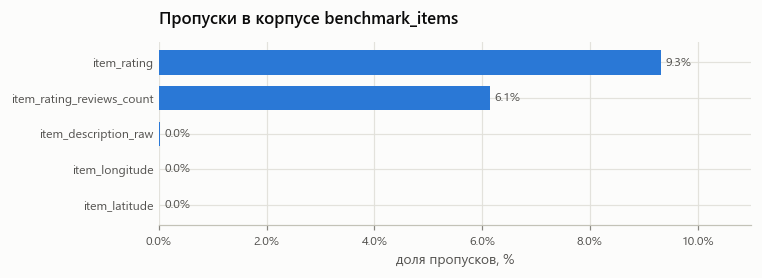

In [9]:
miss = (items.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(7, 2.6))
barh_top(ax, miss.index.tolist(), miss.values, fmt="{:.1f}%")
style(ax, "Пропуски в корпусе benchmark_items", xlabel="доля пропусков, %")
ax.xaxis.set_major_formatter(PercentFormatter())
plt.tight_layout()
plt.show()

Пропуски сосредоточены в «репутационных» полях: `item_rating` (9.3%) и
`item_rating_reviews_count` (6.1%) — это новые продавцы без отзывов. Пропуск
здесь **информативен**, поэтому заполнять его средним нельзя: нужен отдельный
флаг «нет рейтинга».

### 2.2 Дубликаты и аномалии

In [10]:
dup = pd.DataFrame([
    {"проверка": "benchmark_items: дубль item_id",
     "штук": int(items.item_id.duplicated().sum())},
    {"проверка": "benchmark_items: дубль title",
     "штук": int(items.item_title_raw.duplicated().sum())},
    {"проверка": "benchmark_items: дубль title+description",
     "штук": int(items.duplicated(["item_title_raw", "item_description_raw"]).sum())},
    {"проверка": "benchmark_queries: дубль search_query",
     "штук": int(queries.search_query.duplicated().sum())},
    {"проверка": "train: полный дубль строки",
     "штук": int(train.duplicated().sum())},
    {"проверка": "train: дубль пары (query, item_id)",
     "штук": int(train.duplicated(["search_query", "item_id"]).sum())},
])
dup["доля"] = [
    dup.loc[0, "штук"] / len(items), dup.loc[1, "штук"] / len(items),
    dup.loc[2, "штук"] / len(items), dup.loc[3, "штук"] / len(queries),
    dup.loc[4, "штук"] / len(train), dup.loc[5, "штук"] / len(train),
]
dup.style.format({"штук": "{:,.0f}", "доля": "{:.1%}"})

,проверка,штук,доля
0,benchmark_items: дубль item_id,0,0.0%
1,benchmark_items: дубль title,"69,260",36.6%
2,benchmark_items: дубль title+description,"18,754",9.9%
3,benchmark_queries: дубль search_query,0,0.0%
4,train: полный дубль строки,"30,619",6.2%
5,"train: дубль пары (query, item_id)","52,412",10.5%


**36.6% объявлений в корпусе имеют неуникальный заголовок**, 9.9% —
полный дубль «заголовок + описание». Это типичные веерные размещения одного
исполнителя. Для поиска это значит: метрики top-k будут «съедаться»
near-дубликатами, а при обучении такие объявления попадут одновременно в
позитивы и в негативы.

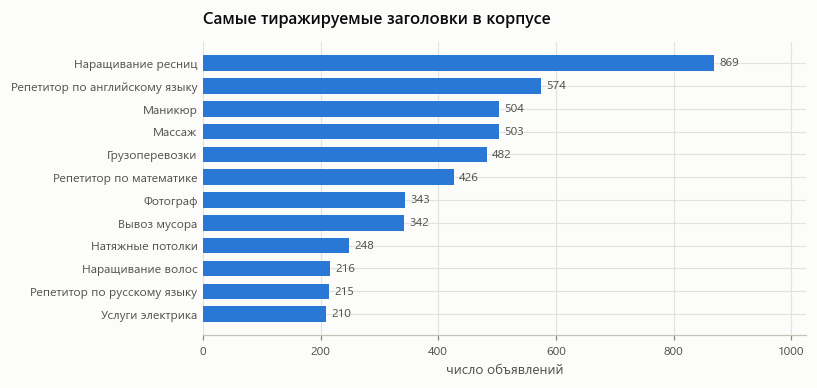

In [11]:
top_dup = (items.item_title_raw.value_counts().head(12))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
labels = [t if len(t) <= 46 else t[:45] + "…" for t in top_dup.index]
barh_top(ax, labels, top_dup.values)
style(ax, "Самые тиражируемые заголовки в корпусе", xlabel="число объявлений")
plt.tight_layout()
plt.show()

In [12]:
price = items.item_price
anom = pd.DataFrame([
    {"аномалия": "цена < 0", "штук": int((price < 0).sum())},
    {"аномалия": "цена = 0", "штук": int((price == 0).sum())},
    {"аномалия": "цена > 1 млн", "штук": int((price > 1e6).sum())},
    {"аномалия": "рейтинг = 0 при наличии", "штук": int((items.item_rating == 0).sum())},
    {"аномалия": "координаты ровно (0, 0)",
     "штук": int(((items.item_latitude == 0) & (items.item_longitude == 0)).sum())},
    {"аномалия": "пустое описание",
     "штук": int((items.item_description_raw.fillna("").str.strip() == "").sum())},
])
print(f"item_price: min={price.min():,.0f}  медиана={price.median():,.0f}  "
      f"p99={price.quantile(0.99):,.0f}  max={price.max():,.0f}")
anom

item_price: min=-1  медиана=1,000  p99=150,000  max=777,777,777,777


,аномалия,штук
0,цена < 0,15248
1,цена = 0,1340
2,цена > 1 млн,627
3,рейтинг = 0 при наличии,3317
4,"координаты ровно (0, 0)",61
5,пустое описание,35


Цена — «грязное» поле: от `-1` (маркер «не указана») до `7.8e11`.
Медиана 1 000 ₽, p99 — 150 000 ₽, то есть максимум завышен на **семь порядков**.
Использовать цену как признак можно только после клиппинга по квантилям и
логарифмирования, а `-1` надо трактовать как отдельную категорию, а не как
число.

## 3. Запросы

### 3.1 Длина и лексика

In [13]:
q_tok = queries.search_query.map(tokenize)
queries["q_n_tokens"] = q_tok.map(len)
queries["q_n_chars"] = queries.search_query.str.len()

train_q = train.search_query.drop_duplicates()
train_q_tok_len = train_q.map(lambda s: len(tokenize(s)))

print(queries[["q_n_tokens", "q_n_chars"]].describe().round(2))

       q_n_tokens  q_n_chars
count      2452.0    2452.00
mean          3.2      22.97
std           1.3       8.86
min           1.0       2.00
25%           2.0      17.00
50%           3.0      22.00
75%           4.0      28.00
max          10.0      70.00


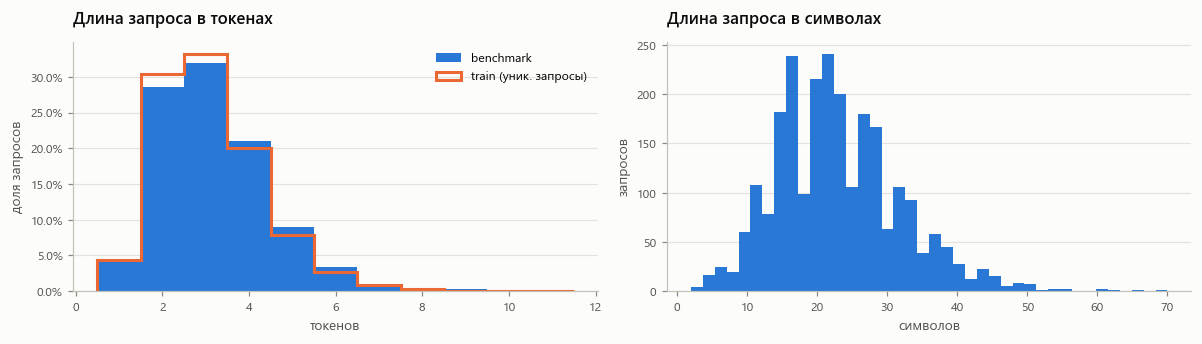

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

bins = np.arange(0.5, 12.5, 1)
axes[0].hist(queries.q_n_tokens, bins=bins, color=SERIES[0],
             weights=np.ones(len(queries)) / len(queries), label="benchmark")
axes[0].hist(train_q_tok_len, bins=bins, histtype="step", linewidth=2,
             color=SERIES[1],
             weights=np.ones(len(train_q_tok_len)) / len(train_q_tok_len),
             label="train (уник. запросы)")
style(axes[0], "Длина запроса в токенах", xlabel="токенов", ylabel="доля запросов")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()

axes[1].hist(queries.q_n_chars, bins=40, color=SERIES[0])
style(axes[1], "Длина запроса в символах", xlabel="символов", ylabel="запросов")
plt.tight_layout()
plt.show()

Запросы очень короткие: **медиана 3 токена**, 75-й перцентиль — 4, максимум
10. Распределения benchmark и train почти совпадают (медиана train — тоже 3),
то есть сдвига домена по длине запроса нет.
Короткий запрос = мало лексического сигнала и высокая неоднозначность, поэтому
контекст (гео, категория, параметры) важен не меньше самого текста.

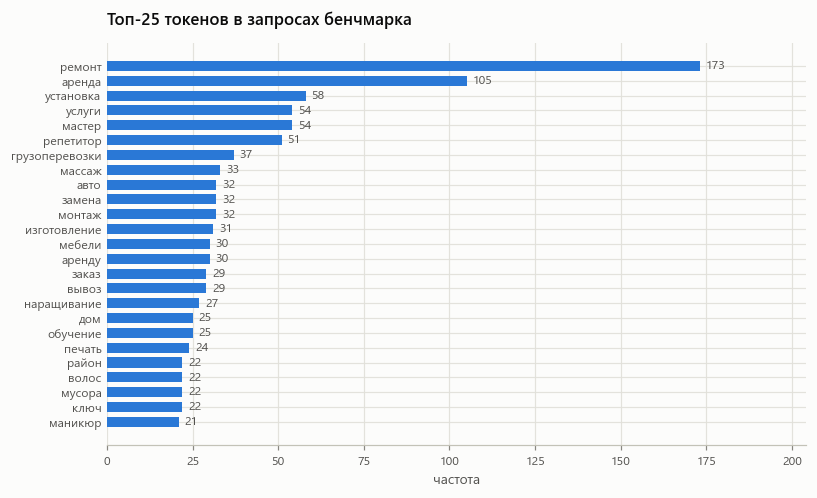

уникальных токенов в запросах: 3,298
токенов, встретившихся 1 раз:  2,421 (73.4%)


In [15]:
all_tokens = [t for toks in q_tok for t in toks if t not in RU_STOP and len(t) > 2]
tok_freq = pd.Series(all_tokens).value_counts()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
top = tok_freq.head(25)
barh_top(ax, top.index.tolist(), top.values)
style(ax, "Топ-25 токенов в запросах бенчмарка", xlabel="частота")
plt.tight_layout()
plt.show()

print(f"уникальных токенов в запросах: {tok_freq.size:,}")
print(f"токенов, встретившихся 1 раз:  {int((tok_freq == 1).sum()):,} "
      f"({pct(int((tok_freq == 1).sum()), tok_freq.size)})")

Лексика запросов — **длинный хвост**: большинство токенов встречается
ровно один раз. Это аргумент против частотных эвристик и в пользу
субсловных / плотных представлений.

### 3.2 Категория, доставка, параметры, гео

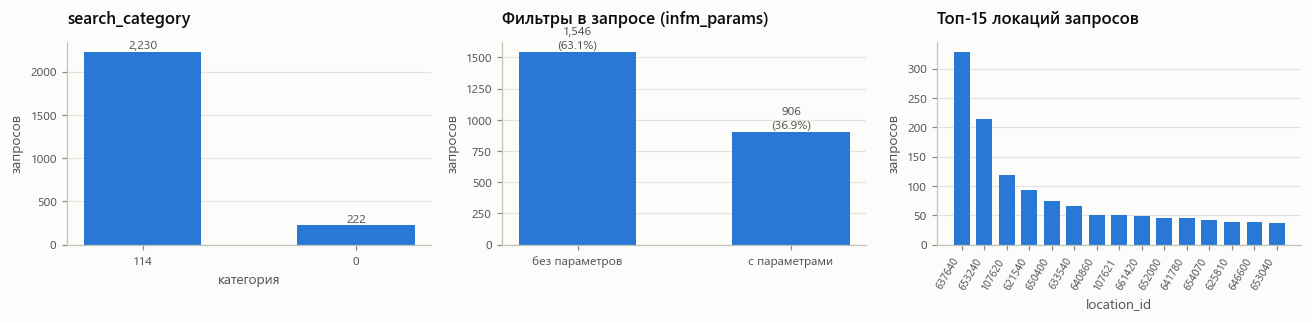

search_is_delivery_search: {0: 2452}
уникальных локаций в запросах: 273


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

cat = queries.search_category.value_counts()
axes[0].bar([str(i) for i in cat.index], cat.values, color=SERIES[0], width=0.55)
style(axes[0], "search_category", xlabel="категория", ylabel="запросов")
for i, v in enumerate(cat.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, color=SECOND)

has_params = (queries.search_infm_params_text.fillna("").str.strip() != "")
axes[1].bar(["без параметров", "с параметрами"],
            [(~has_params).sum(), has_params.sum()], color=SERIES[0], width=0.55)
style(axes[1], "Фильтры в запросе (infm_params)", ylabel="запросов")
for i, v in enumerate([(~has_params).sum(), has_params.sum()]):
    axes[1].text(i, v, f"{v:,}\n({pct(v, len(queries))})", ha="center",
                 va="bottom", fontsize=8, color=SECOND)

loc_top = queries.search_location_id.value_counts().head(15)
axes[2].bar(range(len(loc_top)), loc_top.values, color=SERIES[0], width=0.7)
axes[2].set_xticks(range(len(loc_top)), [str(i) for i in loc_top.index],
                   rotation=60, ha="right", fontsize=7)
style(axes[2], "Топ-15 локаций запросов", xlabel="location_id", ylabel="запросов")

plt.tight_layout()
plt.show()

print(f"search_is_delivery_search: {queries.search_is_delivery_search.value_counts().to_dict()}")
print(f"уникальных локаций в запросах: {queries.search_location_id.nunique():,}")

Три важных факта:

* `search_category` практически константа: 2 230 запросов из 2 452 — категория
  **114 (Услуги)**, остальные 222 — `0` (категория не задана). Как признак
  бесполезна, но задаёт домен: это **поиск по услугам**, а не по товарам.
* `search_is_delivery_search` — **строго 0 во всём бенчмарке** (в `train` единица
  встречается лишь у 12 строк из 497 673). Практически вырожденная колонка:
  обучать на ней нечего, а на бенчмарке она не варьируется вовсе.
* 63% запросов идут **без фильтров**, то есть весь сигнал — в тексте и гео.

## 4. Корпус объявлений

### 4.1 Тексты

In [17]:
def utf8_lengths(path, column):
    """Длины строк без материализации колонки в pandas."""
    tbl = pq.read_table(path, columns=[column])
    lens = pc.utf8_length(tbl.column(column).combine_chunks()).to_numpy(
        zero_copy_only=False).astype("float64")
    del tbl
    return lens


len_title = items.item_title_raw.str.len().to_numpy(dtype="float64")
len_desc = utf8_lengths(FILES["benchmark_items"], "item_description_raw")
len_infm = utf8_lengths(FILES["benchmark_items"], "item_infm_params_text")

text_stats = pd.DataFrame({
    "item_title_raw": pd.Series(len_title).describe(),
    "item_description_raw": pd.Series(len_desc).describe(),
    "item_infm_params_text": pd.Series(len_infm).describe(),
}).round(1)
text_stats

,item_title_raw,item_description_raw,item_infm_params_text
count,189212.0,189177.0,189212.0
mean,33.6,1405.2,973.9
std,12.2,1284.2,875.9
min,1.0,1.0,10.0
25%,24.0,422.0,453.0
50%,35.0,1054.0,738.0
75%,44.0,1978.0,1206.0
max,100.0,8494.0,19068.0


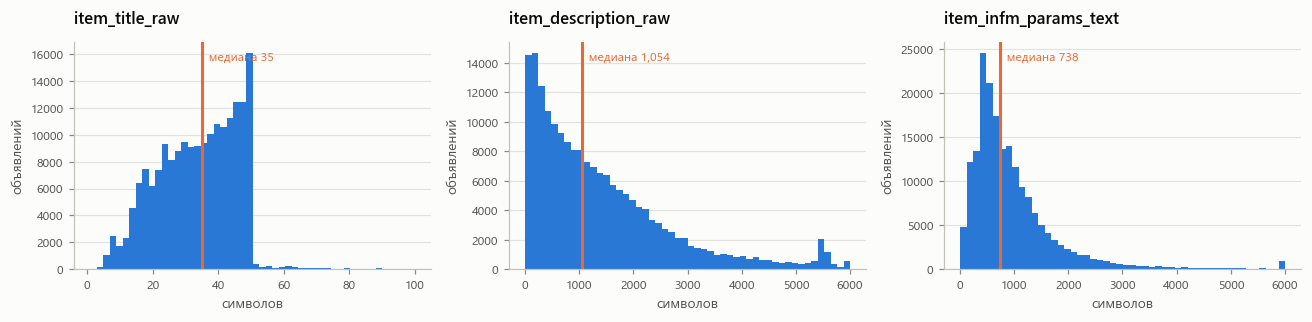

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
specs = [(len_title, "item_title_raw", 100), (len_desc, "item_description_raw", 6000),
         (len_infm, "item_infm_params_text", 6000)]
for ax, (vals, name, clip) in zip(axes, specs):
    v = np.clip(vals[~np.isnan(vals)], 0, clip)
    ax.hist(v, bins=50, color=SERIES[0])
    med = np.nanmedian(vals)
    ax.axvline(med, color=SERIES[1], linewidth=2)
    ax.text(med, ax.get_ylim()[1] * 0.92, f"  медиана {med:,.0f}",
            fontsize=8, color=SERIES[1])
    style(ax, name, xlabel="символов", ylabel="объявлений")
plt.tight_layout()
plt.show()

Заголовок жёстко ограничен **100 символами** (медиана 34) — это очень
короткое поле. Основной объём текста лежит в описании (медиана ~900 символов) и
в параметрах (~870). Для bi-encoder'а с лимитом 512 токенов описание придётся
усекать, и выбор «что именно усечь» станет отдельным решением.

### 4.2 Цена, рейтинг, отзывы

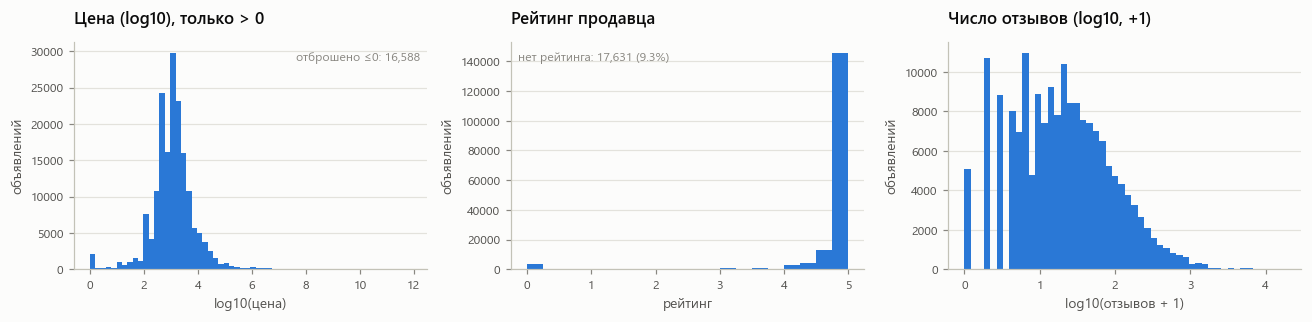

         item_price  item_rating  item_rating_reviews_count
count  1.892120e+05    171581.00                  177597.00
mean   1.986029e+07         4.79                      66.48
std    3.730628e+09         0.74                     230.81
min   -1.000000e+00         0.00                       0.00
25%    3.800000e+02         4.88                       5.00
50%    1.000000e+03         5.00                      18.00
75%    2.500000e+03         5.00                      53.00
95%    1.600000e+04         5.00                     249.00
99%    1.500000e+05         5.00                     796.00
max    7.777778e+11         5.00                   18291.00


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

pos_price = items.item_price[items.item_price > 0]
axes[0].hist(np.log10(pos_price), bins=60, color=SERIES[0])
style(axes[0], "Цена (log10), только > 0", xlabel="log10(цена)", ylabel="объявлений")
axes[0].text(0.98, 0.92, f"отброшено ≤0: {(items.item_price <= 0).sum():,}",
             transform=axes[0].transAxes, ha="right", fontsize=8, color=MUTED)

rating = items.item_rating.dropna()
axes[1].hist(rating, bins=np.arange(0, 5.25, 0.25), color=SERIES[0])
style(axes[1], "Рейтинг продавца", xlabel="рейтинг", ylabel="объявлений")
axes[1].text(0.02, 0.92, f"нет рейтинга: {items.item_rating.isna().sum():,} "
             f"({pct(items.item_rating.isna().sum(), len(items))})",
             transform=axes[1].transAxes, fontsize=8, color=MUTED)

rev = items.item_rating_reviews_count.dropna()
axes[2].hist(np.log10(rev + 1), bins=50, color=SERIES[0])
style(axes[2], "Число отзывов (log10, +1)", xlabel="log10(отзывов + 1)",
      ylabel="объявлений")
plt.tight_layout()
plt.show()

print(items[["item_price", "item_rating", "item_rating_reviews_count"]]
      .describe(percentiles=[.25, .5, .75, .95, .99]).round(2))

Рейтинг сильно смещён к 5.0 (медиана 5.0, p90 = 5.0) — как признак
ранжирования он почти не различает объявления; полезнее производные вроде
«рейтинг × log(отзывы)». Отзывы распределены логнормально с длинным хвостом до
18 291.

### 4.3 География

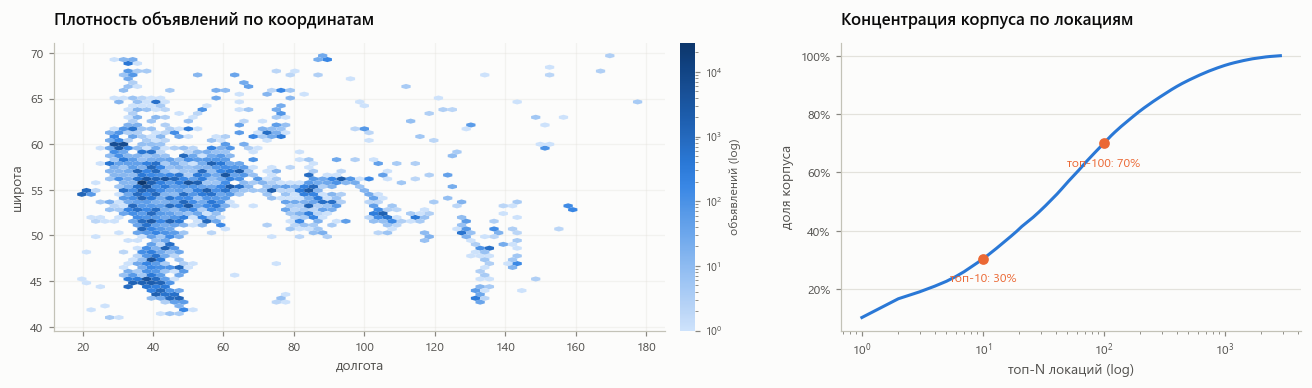

уникальных локаций в корпусе: 2,877
координат вне границ РФ: 169


In [20]:
geo = items[["item_latitude", "item_longitude"]].dropna()
in_ru = geo[(geo.item_latitude.between(41, 70)) & (geo.item_longitude.between(19, 180))]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6),
                         gridspec_kw={"width_ratios": [1.6, 1]})

hb = axes[0].hexbin(in_ru.item_longitude, in_ru.item_latitude, gridsize=60,
                    bins="log", cmap=SEQ_CMAP, mincnt=1, linewidths=0)
style(axes[0], "Плотность объявлений по координатам",
      xlabel="долгота", ylabel="широта", axis="both")
axes[0].grid(alpha=0.35)
cb = fig.colorbar(hb, ax=axes[0], pad=0.02)
cb.set_label("объявлений (log)", color=SECOND, fontsize=8)
cb.ax.tick_params(labelsize=7, color=MUTED)
cb.outline.set_visible(False)

loc_counts = items.item_location_id.value_counts()
share = np.cumsum(loc_counts.values) / loc_counts.sum()
axes[1].plot(np.arange(1, len(share) + 1), share, color=SERIES[0])
axes[1].set_xscale("log")
style(axes[1], "Концентрация корпуса по локациям",
      xlabel="топ-N локаций (log)", ylabel="доля корпуса")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for n in (10, 100):
    if n <= len(share):
        axes[1].plot([n], [share[n - 1]], "o", color=SERIES[1], markersize=6)
        axes[1].text(n, share[n - 1] - 0.08, f"топ-{n}: {share[n - 1]:.0%}",
                     fontsize=8, color=SERIES[1], ha="center")
plt.tight_layout()
plt.show()

print(f"уникальных локаций в корпусе: {items.item_location_id.nunique():,}")
print(f"координат вне границ РФ: {len(geo) - len(in_ru):,}")

### 4.4 Категории и микрокатегории

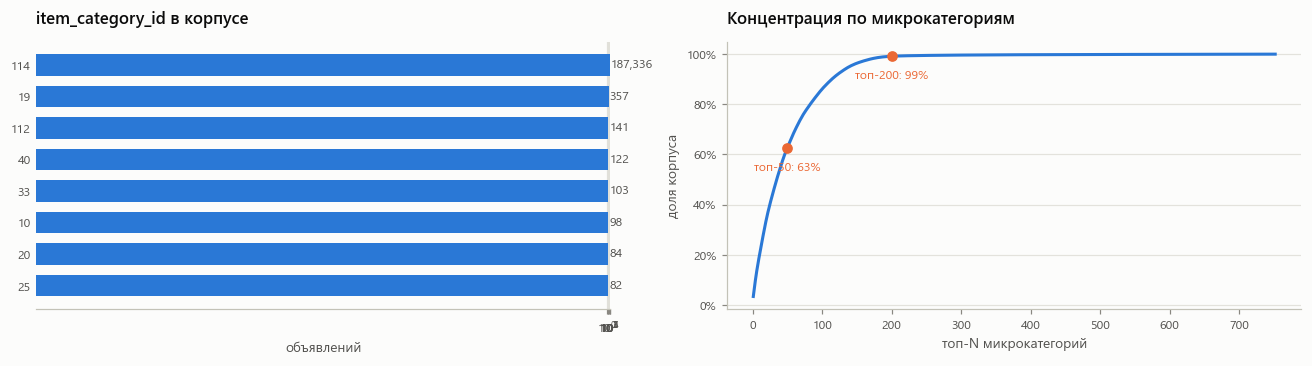

уникальных микрокатегорий: 752
доля категории 114 (Услуги): 99.0%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

cat_counts = items.item_category_id.value_counts().head(8)
barh_top(axes[0], [str(i) for i in cat_counts.index], cat_counts.values)
style(axes[0], "item_category_id в корпусе", xlabel="объявлений")
axes[0].set_xscale("log")

mc = items.item_microcat_id.value_counts()
mshare = np.cumsum(mc.values) / mc.sum()
axes[1].plot(np.arange(1, len(mshare) + 1), mshare, color=SERIES[0])
style(axes[1], "Концентрация по микрокатегориям",
      xlabel="топ-N микрокатегорий", ylabel="доля корпуса")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for n in (50, 200):
    axes[1].plot([n], [mshare[n - 1]], "o", color=SERIES[1], markersize=6)
    axes[1].text(n, mshare[n - 1] - 0.09, f"топ-{n}: {mshare[n - 1]:.0%}",
                 fontsize=8, color=SERIES[1], ha="center")
plt.tight_layout()
plt.show()

print(f"уникальных микрокатегорий: {items.item_microcat_id.nunique():,}")
print(f"доля категории 114 (Услуги): "
      f"{pct((items.item_category_id == 114).sum(), len(items))}")

Корпус **на 99% состоит из категории 114 (Услуги)** — это тот же домен,
что и у запросов. Микрокатегорий 752, и они распределены неравномерно: топ-200
покрывают большую часть корпуса. `item_microcat_id` — самый сильный
категориальный признак для фильтрации кандидатов.

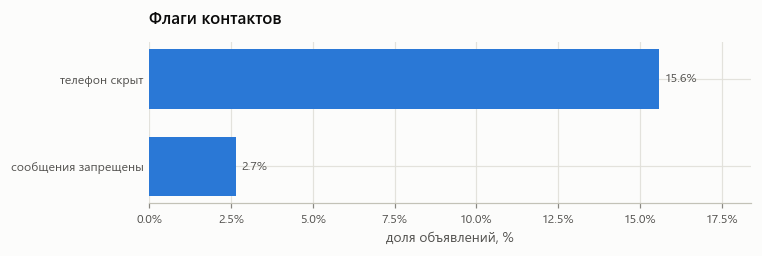

In [22]:
fig, ax = plt.subplots(figsize=(7, 2.4))
flags = pd.Series({
    "телефон скрыт": items.item_is_phone_hidden.mean(),
    "сообщения запрещены": items.item_is_message_forbidden.mean(),
})
barh_top(ax, flags.index.tolist(), flags.values * 100, fmt="{:.1f}%")
style(ax, "Флаги контактов", xlabel="доля объявлений, %")
ax.xaxis.set_major_formatter(PercentFormatter())
plt.tight_layout()
plt.show()

## 5. Структура обучающих пар

Ключевой вопрос: **что здесь является таргетом?** В `train` нет колонки с
меткой релевантности — только пары «запрос → объявление». Значит это
**positives-only** датасет (implicit feedback), и негативы придётся
сэмплировать самостоятельно.

In [23]:
pairs = pd.DataFrame([
    {"метрика": "строк (пар)", "значение": len(train)},
    {"метрика": "уникальных запросов", "значение": train.search_query.nunique()},
    {"метрика": "уникальных объявлений", "значение": train.item_id.nunique()},
    {"метрика": "уникальных пар (query, item)",
     "значение": len(train.drop_duplicates(["search_query", "item_id"]))},
    {"метрика": "повторов пар (query, item)",
     "значение": int(train.duplicated(["search_query", "item_id"]).sum())},
])
pairs.style.format({"значение": "{:,.0f}"})

,метрика,значение
0,строк (пар),"497,673"
1,уникальных запросов,"74,529"
2,уникальных объявлений,"344,825"
3,"уникальных пар (query, item)","445,261"
4,"повторов пар (query, item)","52,412"


52 412 пар (10.5%) повторяются. Повтор пары — это не мусор, а **сигнал
силы**: одна и та же связка «запрос → объявление» зафиксирована несколько раз.
Её стоит использовать как вес примера, а не дедуплицировать вслепую.

In [24]:
items_per_q = train.groupby("search_query").item_id.nunique()
q_per_item = train.groupby("item_id").search_query.nunique()

print("объявлений на запрос:")
print(items_per_q.describe(percentiles=[.5, .75, .9, .99]).round(2))
print("\nзапросов на объявление:")
print(q_per_item.describe(percentiles=[.5, .75, .9, .99]).round(2))

объявлений на запрос:
count    74529.00
mean         5.97
std         50.30
min          1.00
50%          1.00
75%          3.00
90%          7.00
99%         78.00
max       5474.00
Name: item_id, dtype: float64

запросов на объявление:
count    344825.00
mean          1.29
std           0.73
min           1.00
50%           1.00
75%           1.00
90%           2.00
99%           4.00
max          47.00
Name: search_query, dtype: float64


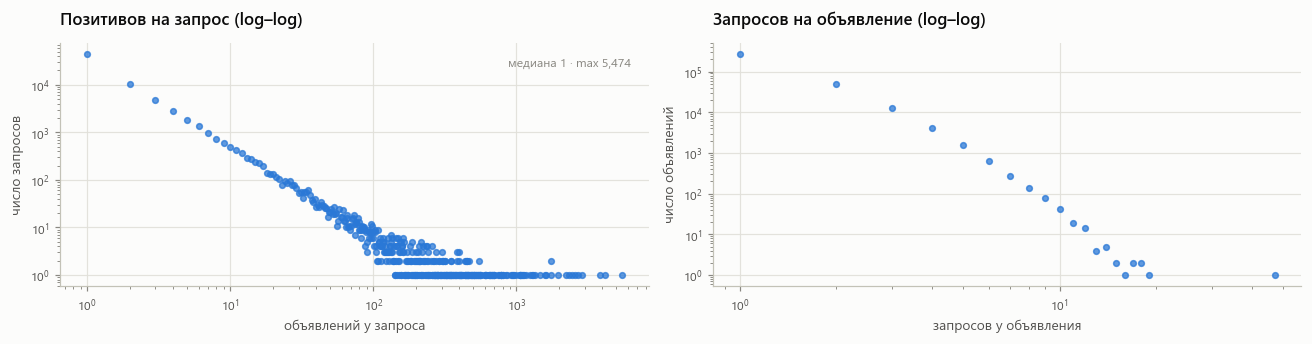

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))

vc = items_per_q.value_counts().sort_index()
axes[0].scatter(vc.index, vc.values, s=14, color=SERIES[0], alpha=0.75)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
style(axes[0], "Позитивов на запрос (log–log)",
      xlabel="объявлений у запроса", ylabel="число запросов", axis="both")
axes[0].text(0.97, 0.9, f"медиана 1 · max {items_per_q.max():,}",
             transform=axes[0].transAxes, ha="right", fontsize=8, color=MUTED)

vc2 = q_per_item.value_counts().sort_index()
axes[1].scatter(vc2.index, vc2.values, s=14, color=SERIES[0], alpha=0.75)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
style(axes[1], "Запросов на объявление (log–log)",
      xlabel="запросов у объявления", ylabel="число объявлений", axis="both")
plt.tight_layout()
plt.show()

Распределение степенное: **медиана — 1 позитив на запрос**, но у
максимума 5 474. Это означает две вещи — большинство запросов дают всего один
обучающий пример (мало сигнала на запрос), и наивное обучение будет
переобучаться на «жирный» хвост частотных запросов. Нужно ограничивать число
пар на запрос при формировании батчей.

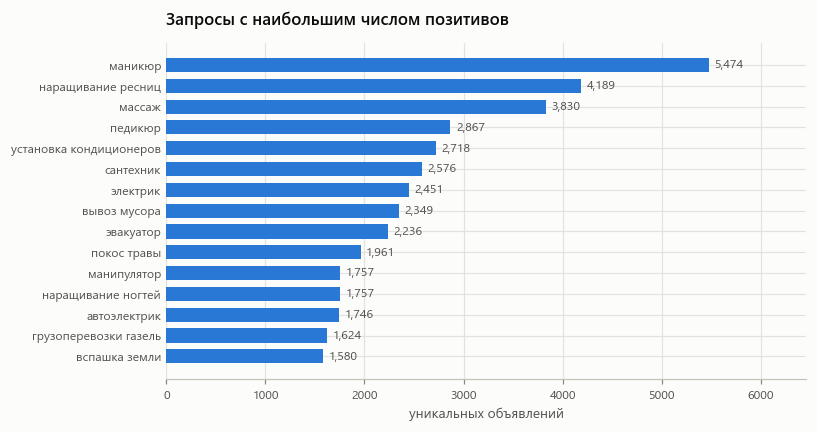

In [26]:
top_q = items_per_q.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7.5, 4))
labels = [q if len(q) <= 40 else q[:39] + "…" for q in top_q.index]
barh_top(ax, labels, top_q.values)
style(ax, "Запросы с наибольшим числом позитивов", xlabel="уникальных объявлений")
plt.tight_layout()
plt.show()

In [27]:
same_loc = (train.search_location_id == train.item_location_id)
train_cat_const = train.search_is_delivery_search.value_counts()

print(f"совпадение локации запроса и объявления: {same_loc.mean():.1%}")
print(f"search_is_delivery_search в train: {train_cat_const.to_dict()}")
print(f"item_category_id == 114 в train: "
      f"{pct((train.item_category_id == 114).sum(), len(train))}")

совпадение локации запроса и объявления: 83.1%
search_is_delivery_search в train: {0: 497661, 1: 12}
item_category_id == 114 в train: 100.0%


**83.1% позитивных пар имеют одинаковый `location_id`** у запроса и
объявления. Гео — сильнейший не-текстовый сигнал: фильтрация кандидатов по
локации отсекает большую часть корпуса почти без потери полноты. Но 17% пар
локацию не совпадают, поэтому жёсткий фильтр обрежет recall — лучше
использовать гео как признак ранжирования или мягкий фильтр.

## 6. Пересечение train ↔ benchmark

Самый важный раздел: понять, **можно ли вообще валидироваться офлайн** и есть
ли утечка.

In [28]:
bench_q = set(queries.search_query)
bench_i = set(items.item_id)
train_q_set = set(train.search_query)
train_i_set = set(train.item_id)

q_overlap = bench_q & train_q_set
i_overlap = bench_i & train_i_set

overlap = pd.DataFrame([
    {"пересечение": "запросы benchmark, встречающиеся в train",
     "штук": len(q_overlap), "база": len(bench_q)},
    {"пересечение": "объявления корпуса, встречающиеся в train",
     "штук": len(i_overlap), "база": len(bench_i)},
])
overlap["доля базы"] = overlap["штук"] / overlap["база"]
overlap.style.format({"штук": "{:,.0f}", "база": "{:,.0f}", "доля базы": "{:.1%}"})

,пересечение,штук,база,доля базы
0,"запросы benchmark, встречающиеся в train",907,"2,452",37.0%
1,"объявления корпуса, встречающиеся в train","18,142","189,212",9.6%


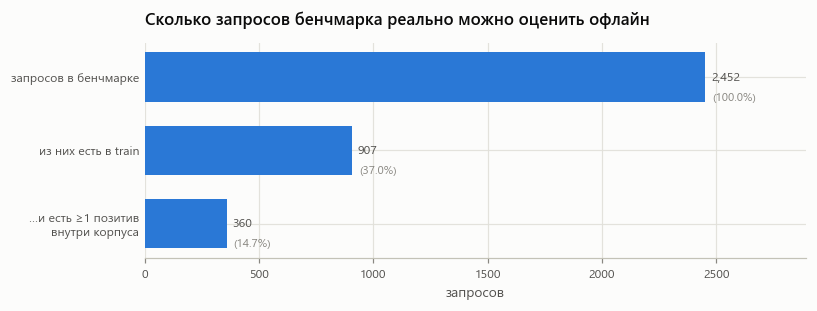

пар (запрос, объявление) с известной релевантностью внутри корпуса: 940
позитивов на запрос в этом подмножестве: 2.61 (медиана 1)


In [29]:
sub = train[train.search_query.isin(bench_q)]
in_corpus = sub.item_id.isin(bench_i)
usable = sub[in_corpus].drop_duplicates(["search_query", "item_id"])
cov_q = usable.search_query.nunique()

funnel = pd.Series({
    "запросов в бенчмарке": len(bench_q),
    "из них есть в train": len(q_overlap),
    "…и есть ≥1 позитив\nвнутри корпуса": cov_q,
})

fig, ax = plt.subplots(figsize=(7.5, 2.9))
barh_top(ax, funnel.index.tolist(), funnel.values)
for i, v in enumerate(funnel.values):
    ax.text(v + funnel.max() * 0.012, i + 0.28, f"({pct(v, len(bench_q))})",
            va="center", fontsize=7.5, color=MUTED)
style(ax, "Сколько запросов бенчмарка реально можно оценить офлайн",
      xlabel="запросов")
plt.tight_layout()
plt.show()

print(f"пар (запрос, объявление) с известной релевантностью внутри корпуса: "
      f"{len(usable):,}")
print(f"позитивов на запрос в этом подмножестве: "
      f"{usable.groupby('search_query').item_id.nunique().mean():.2f} (медиана "
      f"{usable.groupby('search_query').item_id.nunique().median():.0f})")

Это главный вывод всего EDA:

* **36.9%** запросов бенчмарка (907 из 2 452) дословно встречаются в `train` —
  формально это утечка, но воспользоваться ей почти нельзя…
* …потому что **только 9.6%** корпуса пересекается с `train`: у пересекающихся
  запросов лишь **8.8%** их позитивов реально лежат в корпусе бенчмарка.
* В итоге **лишь 360 запросов (14.7%)** имеют хотя бы один известный позитив
  внутри корпуса, в среднем 2.6 позитива на запрос.

Практический смысл: **бенчмарк фактически не размечен**. Полноценного
ground truth нет, и эти 360 запросов — сильно неполный прокси-валидатор
(отсутствие объявления в списке ≠ нерелевантность). Валидацию надо строить на
отложенной части `train`, а 360 запросов использовать только как sanity-check.

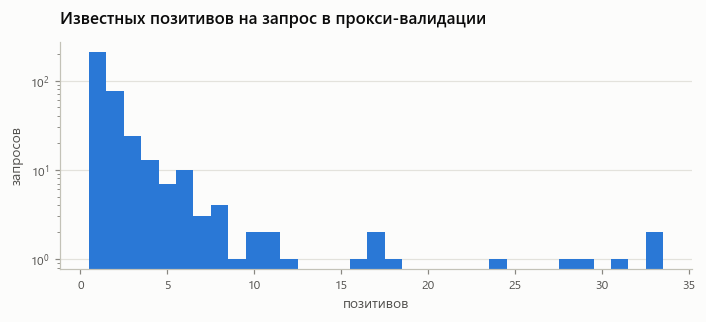

,позитивов в корпусе
search_query,
клининг,33
ремонт газовых котлов,33
перевозка мебели,31
остекление балконов,29
баня,28
грузчики на час,24
депиляция,18
надуть шары гелием,17


In [30]:
val_sizes = usable.groupby("search_query").item_id.nunique()

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(val_sizes, bins=np.arange(0.5, val_sizes.max() + 1.5, 1), color=SERIES[0])
style(ax, "Известных позитивов на запрос в прокси-валидации",
      xlabel="позитивов", ylabel="запросов")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

usable.groupby("search_query").item_id.nunique().sort_values(
    ascending=False).head(8).to_frame("позитивов в корпусе")

## 7. Лексическое пересечение «запрос ↔ объявление»

Проверяем потолок чисто лексического поиска (BM25): какую долю токенов запроса
вообще можно найти в тексте релевантного объявления. Считаем на потоковой
выборке, чтобы не грузить описания целиком.

In [31]:
def sample_columns(path, columns, n, seed=RANDOM_STATE, batch_size=20_000):
    """Потоковая случайная выборка строк — без материализации всей таблицы."""
    gen = np.random.default_rng(seed)
    pf = pq.ParquetFile(path)
    total = pf.metadata.num_rows
    keep_frac = min(1.0, n / total)
    chunks = []
    for batch in pf.iter_batches(batch_size=batch_size, columns=columns):
        df = batch.to_pandas()
        mask = gen.random(len(df)) < keep_frac
        if mask.any():
            chunks.append(df[mask])
        del df
    return pd.concat(chunks, ignore_index=True)


LEX_COLS = ["search_query", "item_title_raw",
            "item_description_raw", "item_infm_params_text"]
lex = sample_columns(FILES["train"], LEX_COLS, SAMPLE_N)
print(f"выборка: {len(lex):,} пар")

выборка: 60,257 пар


In [32]:
q_sets = lex.search_query.map(lambda s: set(tokenize(s)))
t_sets = lex.item_title_raw.map(lambda s: set(tokenize(s)))
d_sets = lex.item_description_raw.map(lambda s: set(tokenize(s)))
p_sets = lex.item_infm_params_text.map(lambda s: set(tokenize(s)))


def coverage(q, *fields):
    """Доля токенов запроса, найденных в объединении полей."""
    out = np.empty(len(q))
    for i, (qs, fs) in enumerate(zip(q, zip(*fields))):
        if not qs:
            out[i] = np.nan
            continue
        union = set().union(*fs)
        out[i] = len(qs & union) / len(qs)
    return out


cov_title = coverage(q_sets, t_sets)
cov_td = coverage(q_sets, t_sets, d_sets)
cov_all = coverage(q_sets, t_sets, d_sets, p_sets)

lex_stats = pd.DataFrame({
    "поле": ["title", "title + description", "title + description + params"],
    "среднее покрытие": [np.nanmean(c) for c in (cov_title, cov_td, cov_all)],
    "медиана": [np.nanmedian(c) for c in (cov_title, cov_td, cov_all)],
    "полное совпадение": [np.nanmean(c == 1) for c in (cov_title, cov_td, cov_all)],
    "нулевое пересечение": [np.nanmean(c == 0) for c in (cov_title, cov_td, cov_all)],
})
lex_stats.style.format({"среднее покрытие": "{:.1%}", "медиана": "{:.1%}",
                        "полное совпадение": "{:.1%}",
                        "нулевое пересечение": "{:.1%}"}).hide(axis="index")

поле,среднее покрытие,медиана,полное совпадение,нулевое пересечение
title,54.8%,50.0%,38.9%,28.2%
title + description,77.0%,100.0%,62.3%,10.7%
title + description + params,82.3%,100.0%,68.8%,7.1%


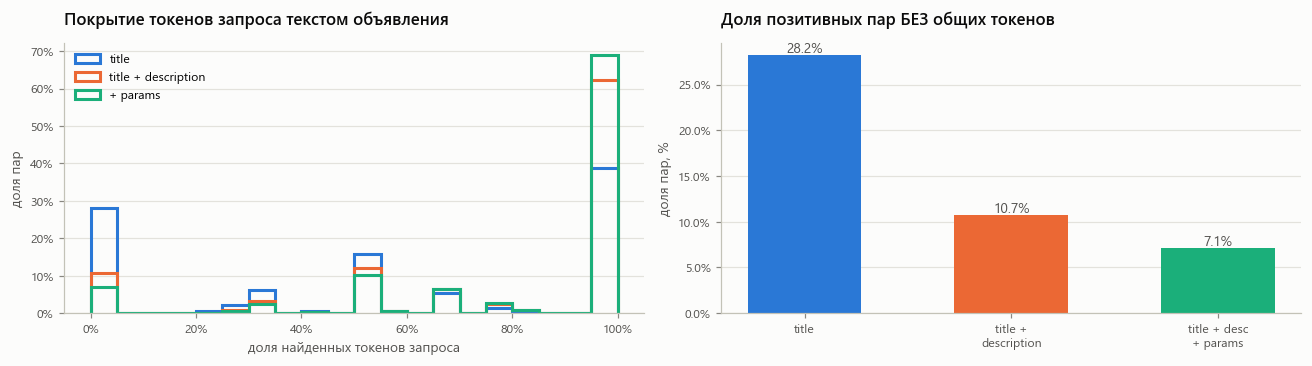

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

bins = np.linspace(0, 1, 21)
for c, name, color in [(cov_title, "title", SERIES[0]),
                       (cov_td, "title + description", SERIES[1]),
                       (cov_all, "+ params", SERIES[2])]:
    c = c[~np.isnan(c)]
    axes[0].hist(c, bins=bins, histtype="step", linewidth=2, color=color,
                 label=name, weights=np.ones(len(c)) / len(c))
style(axes[0], "Покрытие токенов запроса текстом объявления",
      xlabel="доля найденных токенов запроса", ylabel="доля пар")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()

zero = [np.nanmean(c == 0) * 100 for c in (cov_title, cov_td, cov_all)]
names = ["title", "title +\ndescription", "title + desc\n+ params"]
axes[1].bar(names, zero, color=[SERIES[0], SERIES[1], SERIES[2]], width=0.55)
for i, v in enumerate(zero):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom",
                 fontsize=9, color=SECOND)
style(axes[1], "Доля позитивных пар БЕЗ общих токенов",
      ylabel="доля пар, %")
axes[1].yaxis.set_major_formatter(PercentFormatter())
plt.tight_layout()
plt.show()

**Ключевой результат для выбора архитектуры.**

У **28% релевантных пар запрос и заголовок не имеют ни одного общего токена**.
То есть поиск только по заголовку через BM25 структурно не способен найти
больше ~72% позитивов — никакой тюнинг параметров этого не исправит.

Подключение описания снижает долю «непересекающихся» пар до **10.7%**, а
параметров — до **7.1%**. Отсюда два следствия:

1. Лексический baseline обязан индексировать **title + description (+ params)**,
   а не только заголовок.
2. Даже так остаётся ~7-10% пар с чисто семантическим соответствием
   (синонимы, словоформы, перефразировки) — их закроет только плотный
   ретривер. Разумная цель — **гибрид BM25 + dense**.

Напомним и про морфологию: русский язык сильно флективный, поэтому для
лексической части нужна лемматизация/стемминг — иначе «ремонт квартир» не
матчится с «ремонту квартиры».

In [34]:
q_norm = lex.search_query.str.lower().str.strip()
t_norm = lex.item_title_raw.str.lower().str.strip()
exact = (q_norm == t_norm).mean()
substr = np.mean([q in t for q, t in zip(q_norm, t_norm)])

print(f"запрос дословно равен заголовку:      {exact:.2%}")
print(f"запрос — подстрока заголовка:          {substr:.2%}")
print(f"средняя длина запроса / заголовка:     "
      f"{q_norm.str.len().mean():.0f} / {t_norm.str.len().mean():.0f} символов")

запрос дословно равен заголовку:      7.36%
запрос — подстрока заголовка:          35.56%
средняя длина запроса / заголовка:     17 / 33 символов


## 8. Структура `infm_params_text`

Поле выглядит как сплющенные пары «ключ значение», склеенные **без
разделителей**: `Вид услуги Красота, здоровье Тип стоимости за услугу ...`.
Восстановить границы пар без схемы нельзя, поэтому оценим структуру
через частотные n-граммы — они проявляют названия ключей.

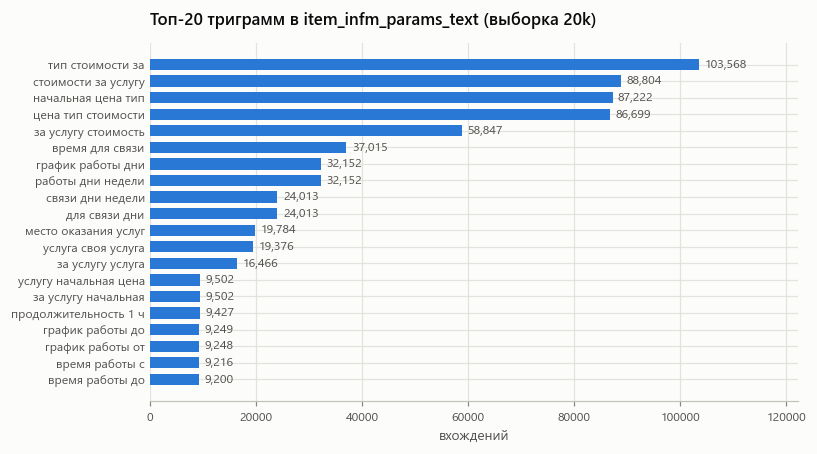

In [35]:
sample_params = items.item_infm_params_text.dropna().sample(
    20_000, random_state=RANDOM_STATE)


def ngrams(texts, n):
    cnt = {}
    for t in texts:
        toks = tokenize(t)
        for i in range(len(toks) - n + 1):
            g = " ".join(toks[i:i + n])
            cnt[g] = cnt.get(g, 0) + 1
    return pd.Series(cnt).sort_values(ascending=False)


tri = ngrams(sample_params, 3).head(20)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
barh_top(ax, tri.index.tolist(), tri.values)
style(ax, "Топ-20 триграмм в item_infm_params_text (выборка 20k)",
      xlabel="вхождений")
plt.tight_layout()
plt.show()

In [36]:
print("Пример полного значения item_infm_params_text:\n")
print(items.item_infm_params_text.dropna().iloc[1][:900], "…")

Пример полного значения item_infm_params_text:

Вид услуги Обучение, курсы Место оказания услуг ул. Чернышевского, 35 Тип услуги Детское развитие, логопеды Тип стоимости за урок Начальная цена График работы от 27000 График работы до 70200 Время работы, с 07:30 Время работы, до 19:30 Начальная цена Тип стоимости за час Стоимость 900 Услуга Обучение чтению Продолжительность 45 мин. Начальная цена Тип стоимости за час Стоимость 600 Услуга Обучение счёту Продолжительность 45 мин. Начальная цена Тип стоимости за час Стоимость 600 Услуга Обучение письму Продолжительность 45 мин. Предмет или специальность Подготовка к школе Опыт работы 4–6 лет Преподаватель Женщина Рабочие дни Понедельник Рабочие дни Вторник Рабочие дни Среда Рабочие дни Четверг Рабочие дни Пятница Рабочие дни Суббота Занятия Индивидуальные Занятия Групповые Как вы работаете У себя Год окончания 2006 Специальность педагогика,нейропсихология Учебное учреждение ВятскийГосударс …


Триграммы подтверждают гипотезу: повторяются служебные ключи
(«вид услуги», «тип стоимости за», «работаете с юрлицами», «рабочие дни …»).
Такой текст на **80% состоит из шаблонных названий полей**, одинаковых у всех
объявлений. Если подавать его в эмбеддер как есть, он будет разбавлять
полезный сигнал: все объявления станут похожи друг на друга. Перед
использованием поле надо либо распарсить по словарю ключей, либо отфильтровать
высокочастотные шаблонные n-граммы.

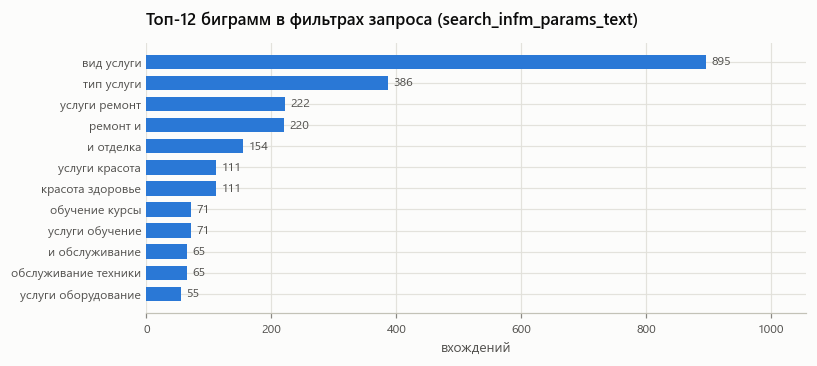

запросов с фильтрами: 36.9%


In [37]:
share_params_q = (queries.search_infm_params_text.fillna("").str.strip() != "").mean()
sample_q_params = queries.search_infm_params_text[
    queries.search_infm_params_text.str.strip() != ""]
bi_q = ngrams(sample_q_params, 2).head(12)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
barh_top(ax, bi_q.index.tolist(), bi_q.values)
style(ax, "Топ-12 биграмм в фильтрах запроса (search_infm_params_text)",
      xlabel="вхождений")
plt.tight_layout()
plt.show()

print(f"запросов с фильтрами: {share_params_q:.1%}")

## 9. Итоговая сводка

In [38]:
summary = pd.DataFrame([
    ("Размер корпуса поиска", f"{len(items):,} объявлений"),
    ("Запросов в бенчмарке", f"{len(queries):,}"),
    ("Обучающих пар", f"{len(train):,} (positives-only, меток релевантности нет)"),
    ("Уникальных запросов в train", f"{train.search_query.nunique():,}"),
    ("Медиана позитивов на запрос", f"{items_per_q.median():.0f}"),
    ("Повторяющихся пар", f"{train.duplicated(['search_query', 'item_id']).sum():,} "
                          f"({pct(train.duplicated(['search_query','item_id']).sum(), len(train))})"),
    ("Домен", "99% — категория 114 «Услуги»"),
    ("Медиана длины запроса", f"{queries.q_n_tokens.median():.0f} токена"),
    ("Дубли заголовков в корпусе", pct(items.item_title_raw.duplicated().sum(), len(items))),
    ("Совпадение гео в позитивных парах", f"{same_loc.mean():.1%}"),
    ("Пары без общих токенов (title)", f"{np.nanmean(cov_title == 0):.1%}"),
    ("Пары без общих токенов (все поля)", f"{np.nanmean(cov_all == 0):.1%}"),
    ("Запросов бенчмарка в train", f"{len(q_overlap):,} ({pct(len(q_overlap), len(bench_q))})"),
    ("Корпус ∩ train", f"{len(i_overlap):,} ({pct(len(i_overlap), len(bench_i))})"),
    ("Запросов с известным позитивом", f"{cov_q:,} ({pct(cov_q, len(bench_q))})"),
    ("Вырожденные колонки",
     f"search_is_delivery_search: 0 у 100% бенчмарка, "
     f"1 лишь у {int((train.search_is_delivery_search == 1).sum())} строк train"),
], columns=["показатель", "значение"])
summary.style.hide(axis="index")

показатель,значение
Размер корпуса поиска,"189,212 объявлений"
Запросов в бенчмарке,"2,452"
Обучающих пар,"497,673 (positives-only, меток релевантности нет)"
Уникальных запросов в train,"74,529"
Медиана позитивов на запрос,1
Повторяющихся пар,"52,412 (10.5%)"
Домен,99% — категория 114 «Услуги»
Медиана длины запроса,3 токена
Дубли заголовков в корпусе,36.6%
Совпадение гео в позитивных парах,83.1%


## 10. Выводы и следствия для модели

### Что за задача

Полнотекстовый поиск по **услугам** (категория 114): 2 452 коротких запроса
против корпуса из 189 212 объявлений. `train` — 497 673 денормализованные пары
«запрос → объявление» **без меток релевантности**, то есть implicit positives.

### Главные ограничения, найденные в данных

1. **Разметки бенчмарка нет.** Только 14.7% запросов имеют хотя бы один
   известный позитив внутри корпуса (360 из 2 452), в среднем 2.6 штуки.
   Офлайн-валидацию нужно строить на отложенной части `train` с разбиением
   **по запросу** (иначе один и тот же запрос попадёт и в train, и в val, а
   37% запросов бенчмарка уже присутствуют в обучении).
2. **Негативов нет.** Их придётся генерировать: in-batch negatives на старте,
   затем hard negatives, добытые первым же ретривером (BM25 или dense) с
   аккуратной чисткой ложных негативов — учитывая, что 36.6% объявлений имеют
   дублирующийся заголовок, «негатив» легко окажется копией позитива.
3. **Лексики недостаточно.** 28% позитивов не делят с заголовком ни одного
   токена. BM25 только по заголовку упирается в потолок ~72% recall.

### Рекомендуемый baseline

* **Текстовое поле для индексации:** `title + description` (+ очищенные
  `params`). Одного заголовка (медиана 34 символа) мало.
* **Нормализация:** лемматизация под русскую морфологию, приведение регистра,
  чистка шаблонных n-грамм из `infm_params_text`.
* **Ретрив:** гибрид — BM25 (лексика, опечатки, редкие токены) + bi-encoder на
  многоязычной / русской модели (синонимы, перефразировки), объединение через
  RRF.
* **Ранжирование:** cross-encoder поверх топ-50/100 кандидатов, на вход —
  текст плюс признаки: совпадение `location_id` (83% позитивов), совпадение
  `microcat_id`, рейтинг × log(отзывы), лог-цена с клиппингом.
* **Дедупликация выдачи** по `(title, description)` — иначе топ забьётся
  копиями одного исполнителя.

### Что выбросить или починить

| Поле | Что делать |
|---|---|
| `search_is_delivery_search` | 0 на всём бенчмарке (12 единиц в train) — удалить |
| `search_category` | почти константа (114 / 0) — низкая ценность |
| `item_price` | клиппинг по p1–p99 + log; `-1` → отдельный флаг «не указана» |
| `item_rating` | 9.3% пропусков — отдельный флаг, не заполнять средним |
| `item_latitude/longitude` | 61 объявление в точке (0, 0) — считать пропуском |
| `item_infm_params_text` | распарсить или отфильтровать шаблонные ключи |

### Что стоит проверить дальше

* Насколько распределение запросов бенчмарка отличается от `train` по
  микрокатегориям (проверка сдвига домена).
* Долю опечаток в запросах — она определит, нужен ли fuzzy-матчинг.
* Качество прокси-валидации на 360 запросах против разбиения `train` —
  совпадает ли ранжирование моделей.
